# Tratamento da Estação Campo Grande

Este notebook organiza o tratamento horário da Estação `Campo Grande` em quatro blocos simples:

1. padronizar o calendário horário;
2. interpolar apenas lacunas internas curtas;
3. validar o impacto do tratamento.

A proposta aqui é fazer o básico bem feito, de forma rastreável e reutilizável para as próximas estações.

## Bibliotecas e configurações

Começamos carregando as bibliotecas que serão usadas ao longo do notebook e localizando automaticamente a raiz do projeto. Isso evita depender do diretório manual de execução do notebook.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

## Carregamento da base da estação

Nesta etapa, carregamos a base consolidada de qualidade do ar, normalizamos o nome da estação para evitar problemas de codificação e isolamos apenas os registros da estação `Campo Grande`.

In [2]:
url_air_quality_data = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/MonitorAr/InitialMergedData/merged_air_quality_data.csv"

df_air_quality = pd.read_csv(url_air_quality_data)
df_campo_grande = df_air_quality[df_air_quality["Nome"] == "ESTAÇÃO CAMPO GRANDE"].copy()

df_campo_grande["data"] = pd.to_datetime(df_campo_grande["data"])
df_campo_grande = df_campo_grande.sort_values("data").reset_index(drop=True)
df_campo_grande = df_campo_grande.drop_duplicates(subset="data", keep="first")
df_campo_grande = df_campo_grande.set_index("data").sort_index().copy()

print("Dimensoes da base da Estacao Campo Grande:", df_campo_grande.shape)
display(df_campo_grande.head())

Dimensoes da base da Estacao Campo Grande: (61368, 14)


,Nome,chuva,temp,ur,so2,no2,co,no,nox,o3,pm10,pm2_5,lat,lon
data,,,,,,,,,,,,,,
2012-01-01 00:30:00,ESTAÇÃO CAMPO GRANDE,0.2,25.12,94.33,3.83,28.79,0.69,1.59,30.38,37.67,27.0,NaN,-22.886255,-43.556522
2012-01-01 01:30:00,ESTAÇÃO CAMPO GRANDE,0.0,25.02,94.65,1.63,25.73,0.58,1.46,27.19,41.29,NaN,NaN,-22.886255,-43.556522
2012-01-01 02:30:00,ESTAÇÃO CAMPO GRANDE,0.2,24.95,92.03,0.38,18.15,0.38,1.05,19.20,48.89,41.0,NaN,-22.886255,-43.556522
2012-01-01 03:30:00,ESTAÇÃO CAMPO GRANDE,0.4,24.82,91.98,0.18,12.09,0.27,0.39,12.48,57.66,16.0,NaN,-22.886255,-43.556522
2012-01-01 04:30:00,ESTAÇÃO CAMPO GRANDE,0.0,24.86,92.73,0.04,15.11,0.30,0.47,15.58,49.09,6.0,NaN,-22.886255,-43.556522


## Resumo das faltas antes do tratamento

Com o calendário padronizado, agora medimos o tamanho do problema de missing antes de qualquer imputação. Essa tabela serve como linha de base para comparar o efeito do tratamento depois.

In [3]:
variaveis_ambientais = [
'no',
'no2',
'so2',
'pm2_5',
'nox',
'ur',
'temp',
'o3',
'co',
'pm10',
'chuva'
]
    

def resumir_faltantes(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    total_linhas = len(df)
    resumo = pd.DataFrame(index=variaveis)
    resumo["faltantes"] = [int(df[col].isna().sum()) for col in variaveis]
    resumo["missing_pct"] = [round(100 * df[col].isna().mean(), 2) for col in variaveis]
    resumo["validos"] = total_linhas - resumo["faltantes"]
    return resumo.sort_values("faltantes", ascending=False)


resumo_missing_antes = resumir_faltantes(df_campo_grande, variaveis_ambientais)
display(resumo_missing_antes)

,faltantes,missing_pct,validos
pm2_5,61368,100.00,0
ur,21024,34.26,40344
so2,7824,12.75,53544
no,4813,7.84,56555
nox,4808,7.83,56560
no2,4785,7.80,56583
pm10,4701,7.66,56667
o3,4235,6.90,57133
co,2698,4.40,58670
temp,1177,1.92,60191


## Regra de imputação adotada

O tratamento escolhido aqui é propositalmente conservador:

- interpolar apenas lacunas internas de até `4` horas consecutivas;
- não extrapolar bordas da série;
- não interpolar `chuva`, porque a interpolação linear pode criar eventos artificiais.

Com isso, preservamos a rastreabilidade do tratamento e evitamos preencher ausências longas ou estruturalmente mais problemáticas.

In [4]:
MAX_GAP_HORAS = 4

variaveis_interpolar = [
    "temp",
    "ur",
    "so2",
    "no2",
    "co",
    "no",
    "nox",
    "o3",
    "pm10",
    "pm2_5",
]


def mascara_lacunas_internas_curtas(serie: pd.Series, max_gap: int = 4) -> pd.Series:
    faltante = serie.isna()
    if not faltante.any():
        return pd.Series(False, index=serie.index)

    grupos = faltante.ne(faltante.shift(fill_value=False)).cumsum()
    tamanho_grupo = faltante.groupby(grupos).transform("sum")
    tem_valor_antes = serie.ffill().notna()
    tem_valor_depois = serie.bfill().notna()

    return faltante & tem_valor_antes & tem_valor_depois & (tamanho_grupo <= max_gap)

df_campo_grande_tratado = df_campo_grande.copy()

registros_imputacao = []

for variavel in variaveis_ambientais:
    serie_original = df_campo_grande[variavel]

    if variavel in variaveis_interpolar:
        mascara_gap_curto = mascara_lacunas_internas_curtas(serie_original, max_gap=MAX_GAP_HORAS)
        serie_interpolada = serie_original.interpolate(method="time", limit_area="inside")
        df_campo_grande_tratado.loc[mascara_gap_curto, variavel] = serie_interpolada.loc[mascara_gap_curto]
        valores_imputados = int((mascara_gap_curto & serie_interpolada.notna()).sum())
        metodo = "interpolate_time"

    else:
        mascara_gap_curto = pd.Series(False, index=serie_original.index)
        valores_imputados = 0
        metodo = "sem_interpolacao"



    registros_imputacao.append(
        {
            "variavel": variavel,
            "metodo": metodo,
            "faltantes_antes": int(serie_original.isna().sum()),
            "faltantes_depois": int(df_campo_grande_tratado[variavel].isna().sum()),
            "valores_imputados": valores_imputados,
        }
    )

resumo_imputacao = pd.DataFrame(registros_imputacao).sort_values(
    ["valores_imputados", "faltantes_antes"],
    ascending=[False, False],
)

display(resumo_imputacao)

,variavel,metodo,faltantes_antes,faltantes_depois,valores_imputados
0,no,interpolate_time,4813,2657,2156
4,nox,interpolate_time,4808,2662,2146
1,no2,interpolate_time,4785,2652,2133
2,so2,interpolate_time,7824,5955,1869
9,pm10,interpolate_time,4701,3663,1038
8,co,interpolate_time,2698,2263,435
7,o3,interpolate_time,4235,3822,413
5,ur,interpolate_time,21024,20756,268
6,temp,interpolate_time,1177,1026,151
3,pm2_5,interpolate_time,61368,61368,0


## Validação do impacto do tratamento

Depois da imputação, validamos o impacto em duas frentes:

- redução do missing por variável;
- estabilidade de estatísticas básicas antes e depois do tratamento.

Como a regra de imputação é curta e conservadora, a expectativa é reduzir uma parte das lacunas sem alterar de forma relevante o comportamento geral das séries.

Total de valores imputados: 10609


,faltantes_antes,missing_pct_antes,faltantes_depois,missing_pct_depois,reducao_absoluta,reducao_relativa_pct
no,4813,7.84,2657,4.33,2156,44.80
nox,4808,7.83,2662,4.34,2146,44.63
no2,4785,7.80,2652,4.32,2133,44.58
so2,7824,12.75,5955,9.70,1869,23.89
pm10,4701,7.66,3663,5.97,1038,22.08
co,2698,4.40,2263,3.69,435,16.12
o3,4235,6.90,3822,6.23,413,9.75
ur,21024,34.26,20756,33.82,268,1.27
temp,1177,1.92,1026,1.67,151,12.83
pm2_5,61368,100.00,61368,100.00,0,0.00


,media_antes,mediana_antes,desvio_padrao_antes,media_depois,mediana_depois,desvio_padrao_depois,delta_media,delta_desvio_padrao
no,24.455455,11.570,34.611055,24.012084,11.23,34.300794,-0.443371,-0.310260
no2,33.744465,31.300,16.735260,33.448295,30.93,16.705672,-0.296170,-0.029588
so2,2.549833,1.450,4.027022,2.547656,1.46,3.997049,-0.002177,-0.029973
nox,58.206221,45.410,45.251297,57.465398,44.68,44.981400,-0.740823,-0.269897
ur,71.903738,74.355,19.028972,71.971472,74.45,19.049930,0.067734,0.020957
temp,27.563329,26.880,4.810969,27.564758,26.88,4.812321,0.001429,0.001352
o3,32.272211,26.040,29.170775,32.352144,26.16,29.198890,0.079932,0.028115
co,0.385994,0.340,0.249019,0.386082,0.34,0.248785,0.000089,-0.000234
pm10,34.196852,30.000,20.797780,34.225336,30.00,20.789437,0.028484,-0.008343
chuva,0.131855,0.000,1.126338,0.131855,0.00,1.126338,0.000000,0.000000


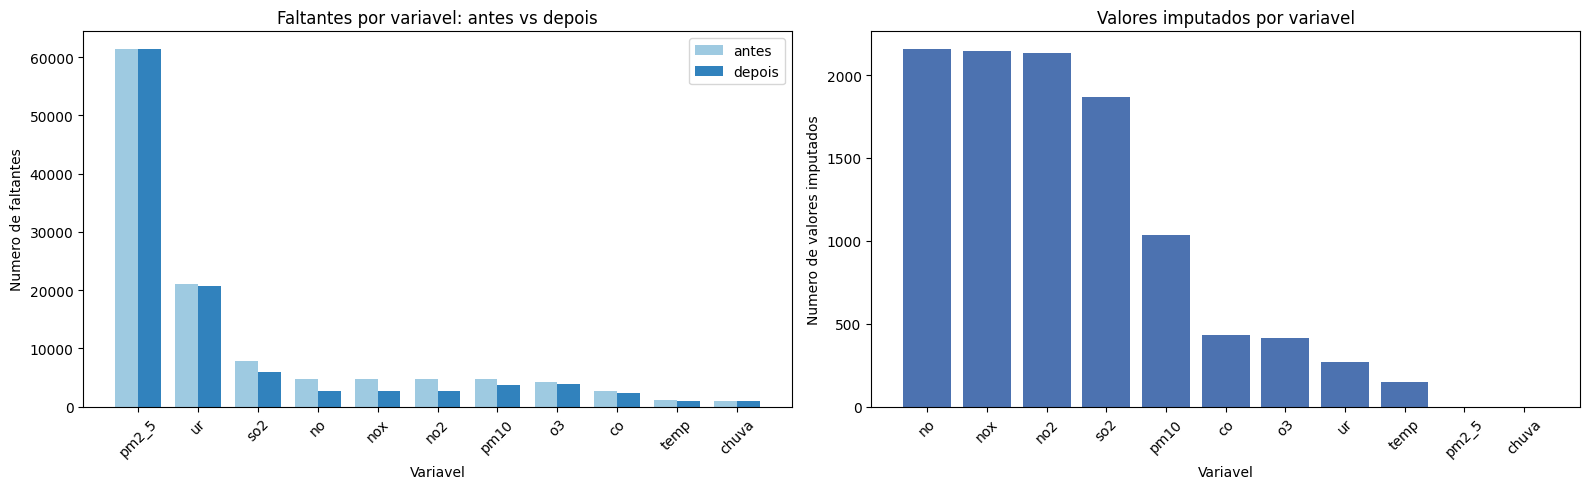

In [5]:
def estatisticas_basicas(df: pd.DataFrame, variaveis: list[str]) -> pd.DataFrame:
    resumo = pd.DataFrame(index=variaveis)
    resumo["media"] = [df[col].mean() for col in variaveis]
    resumo["mediana"] = [df[col].median() for col in variaveis]
    resumo["desvio_padrao"] = [df[col].std() for col in variaveis]
    return resumo


resumo_missing_depois = resumir_faltantes(df_campo_grande_tratado, variaveis_ambientais)

comparativo_missing = resumo_missing_antes[["faltantes", "missing_pct"]].rename(
    columns={
        "faltantes": "faltantes_antes",
        "missing_pct": "missing_pct_antes",
    }
).join(
    resumo_missing_depois[["faltantes", "missing_pct"]].rename(
        columns={
            "faltantes": "faltantes_depois",
            "missing_pct": "missing_pct_depois",
        }
    )
)
comparativo_missing["reducao_absoluta"] = (
    comparativo_missing["faltantes_antes"] - comparativo_missing["faltantes_depois"]
)
comparativo_missing["reducao_relativa_pct"] = (
    100 * comparativo_missing["reducao_absoluta"] / comparativo_missing["faltantes_antes"].replace(0, pd.NA)
).round(2)

variaveis_com_dados = [
    variavel
    for variavel in variaveis_ambientais
    if df_campo_grande[variavel].notna().any() or df_campo_grande_tratado[variavel].notna().any()
]

estatisticas_antes = estatisticas_basicas(df_campo_grande, variaveis_com_dados).add_suffix("_antes")
estatisticas_depois = estatisticas_basicas(df_campo_grande_tratado, variaveis_com_dados).add_suffix("_depois")
comparativo_estatistico = estatisticas_antes.join(estatisticas_depois)
comparativo_estatistico["delta_media"] = (
    comparativo_estatistico["media_depois"] - comparativo_estatistico["media_antes"]
)
comparativo_estatistico["delta_desvio_padrao"] = (
    comparativo_estatistico["desvio_padrao_depois"] - comparativo_estatistico["desvio_padrao_antes"]
)

print(f"Total de valores imputados: {int(resumo_imputacao['valores_imputados'].sum())}")
display(comparativo_missing.sort_values("reducao_absoluta", ascending=False))
display(comparativo_estatistico)

comparativo_missing_plot = comparativo_missing.reset_index(names="variavel")
resumo_imputacao_plot = resumo_imputacao.sort_values("valores_imputados", ascending=False)

x_missing = range(len(comparativo_missing_plot))
largura = 0.38
x_imputacao = range(len(resumo_imputacao_plot))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(
    [x - largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_antes"],
    width=largura,
    label="antes",
    color="#9ecae1",
)
axes[0].bar(
    [x + largura / 2 for x in x_missing],
    comparativo_missing_plot["faltantes_depois"],
    width=largura,
    label="depois",
    color="#3182bd",
)
axes[0].set_title("Faltantes por variavel: antes vs depois")
axes[0].set_xlabel("Variavel")
axes[0].set_ylabel("Numero de faltantes")
axes[0].set_xticks(list(x_missing))
axes[0].set_xticklabels(comparativo_missing_plot["variavel"], rotation=45)
axes[0].legend()

axes[1].bar(
    list(x_imputacao),
    resumo_imputacao_plot["valores_imputados"],
    color="#4c72b0",
)
axes[1].set_title("Valores imputados por variavel")
axes[1].set_xlabel("Variavel")
axes[1].set_ylabel("Numero de valores imputados")
axes[1].set_xticks(list(x_imputacao))
axes[1].set_xticklabels(resumo_imputacao_plot["variavel"], rotation=45)

plt.tight_layout()
plt.show()

## Salvamento da base tratada

Por fim, salvamos a série horária tratada da Estação `Campo Grande`. A base final inclui:

- calendário horário padronizado;
- variáveis tratadas.

Essa saída já fica pronta para ser reutilizada na etapa de unificação das estações.

In [6]:
project_root = Path().resolve().parents[4]
output_dir = project_root / "Data" / "IntermediaryData" / "MonitorAr" / "TreatedStations"
output_dir.mkdir(parents=True, exist_ok=True)

df_campo_grande_tratado_saida = df_campo_grande_tratado.reset_index()

output_csv_path = output_dir / "campo_grande_tratado.csv"
df_campo_grande_tratado_saida.to_csv(output_csv_path, index=False, encoding="utf-8")

print(f"Arquivo salvo em: {output_csv_path}")

Arquivo salvo em: C:\Users\João Henrique\OneDrive - cefet-rj.br\Projetos-2026\qualiar\Data\IntermediaryData\MonitorAr\TreatedStations\campo_grande_tratado.csv
